# Notebook 06: Descomposición Vectorial de la Fuerza de Marea
**Autor:** Iván Andrés Mena Contreras
**Proyecto:** Lunar Tidal Triggering of Earthquakes

En el paso anterior detectamos que la dinámica orbital ($dF/dt$) presenta ciertas acumulaciones. Sin embargo, para que el estrés de marea "gatille" una falla, la fuerza no solo debe existir, debe estar orientada adecuadamente respecto al plano de la falla.

**Objetivo:** Modelar la influencia lunar como un vector topocéntrico (visto desde la perspectiva exacta del hipocentro en el momento de la ruptura). Calcularemos los componentes de **Esfuerzo Normal** (que facilita el deslizamiento separando las paredes de la falla) y **Esfuerzo Cortante** (que empuja el bloque en la dirección del deslizamiento), e integraremos esto con nuestra tasa de cambio $dF/dt$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skyfield.api import load, wgs84
from tqdm import tqdm
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
os.makedirs('../results/figures', exist_ok=True)

# Cargar el dataset del Notebook 05
data_path = '../data/processed/earthquakes_lag_analysis.csv'
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True)

print(f"Dataset cargado con {len(df)} eventos. Listos para análisis vectorial.")

Dataset cargado con 56 eventos. Listos para análisis vectorial.


## 1. Coordenadas Topocéntricas
Utilizamos la librería astronómica de alta precisión `skyfield` para calcular dónde estaba exactamente la Luna en el cielo del observador (el sismo) en el momento de ruptura. El ángulo de altitud lunar dicta cómo la fuerza gravitacional tira de la falla.

In [2]:
# Configurar Skyfield
ts = load.timescale()
eph = load('de421.bsp')
luna = eph['moon']
tierra = eph['earth']

df['moon_altitude'] = np.nan
df['moon_azimuth'] = np.nan

print("Calculando vectores topocéntricos con Skyfield...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        # Convertir tiempo
        t = ts.from_datetime(row['time'])
        
        # El observador es el hipocentro del sismo. Elevación es negativa por ser subterráneo.
        elevacion_m = -row['depth'] * 1000
        observador = tierra + wgs84.latlon(row['latitude'], row['longitude'], elevation_m=elevacion_m)
        
        # Observar la Luna desde este punto
        astrometric = observador.at(t).observe(luna)
        apparent = astrometric.apparent()
        
        # Obtener Altitud (sobre el horizonte local) y Azimut
        alt, az, distance = apparent.altaz()
        
        df.loc[idx, 'moon_altitude'] = alt.degrees
        df.loc[idx, 'moon_azimuth'] = az.degrees
    except Exception as e:
        print(f"Error procesando {row['id']}: {e}")

print("Vectores topocéntricos calculados con éxito.")
df[['id', 'moon_altitude', 'moon_azimuth']].head()

[                                 ]   0% de421.bsp

[                                 ]   1% de421.bsp

[#                                ]   3% de421.bsp

[#                                ]   4% de421.bsp

[##                               ]   7% de421.bsp

...

  0%|          | 0/56 [00:00<?, ?it/s]

 73%|███████▎  | 41/56 [00:00<00:00, 402.08it/s]

100%|██████████| 56/56 [00:00<00:00, 400.23it/s]

Vectores topocéntricos calculados con éxito.


,id,moon_altitude,moon_azimuth
0,usp0006ww5,33.450662,76.802118
1,usp0007788,6.453201,113.157658
2,usp0007dmb,-12.840886,88.451815
3,usp0007j1e,60.294798,174.226054
4,usp00084m2,79.254533,116.725374


## 2. Esfuerzo Vectorial de Marea
Aproximamos la proyección del vector de fuerza gravitacional de la Luna ($F \propto 1/d^3$) en dos componentes principales respecto al plano horizontal:
- **Esfuerzo Normal (Normal Stress):** Componente perpendicular, proporcional a $\sin(Altitud)$. Promueve el *unclamping* (desbloqueo de la falla).
- **Esfuerzo Cortante (Shear Stress):** Componente paralelo, proporcional a $\cos(Altitud)$. Aumenta la cizalladura lateral.

In [3]:
# La fuerza de marea decae con el cubo de la distancia
fuerza_magnitud = 1.0 / (df['moon_distance_au']**3)

# Angulo de altitud en radianes
alt_rad = np.radians(df['moon_altitude'])

# Componentes de Coulomb
# Note: Asumimos geometría genérica de falla (idealización para análisis estadístico global)
df['tidal_normal_stress'] = fuerza_magnitud * np.sin(alt_rad)
df['tidal_shear_stress'] = fuerza_magnitud * np.cos(alt_rad)

# Normalizamos para que las escalas sean interpretables (unidades relativas)
df['tidal_normal_stress'] = df['tidal_normal_stress'] / df['tidal_normal_stress'].max()
df['tidal_shear_stress'] = df['tidal_shear_stress'] / df['tidal_shear_stress'].max()

print("Tensores de estrés calculados.")

Tensores de estrés calculados.


## 3. Visualización Física (Espacio de Coulomb)
Ploteamos nuestros eventos en el espacio 2D de los esfuerzos de Coulomb generados por la marea, utilizando nuestra tasa dinámica $dF/dt$ como un mapa de calor divergente.

Gráfico de espacio vectorial guardado en: ../results/figures/06_coulomb_vectors.png


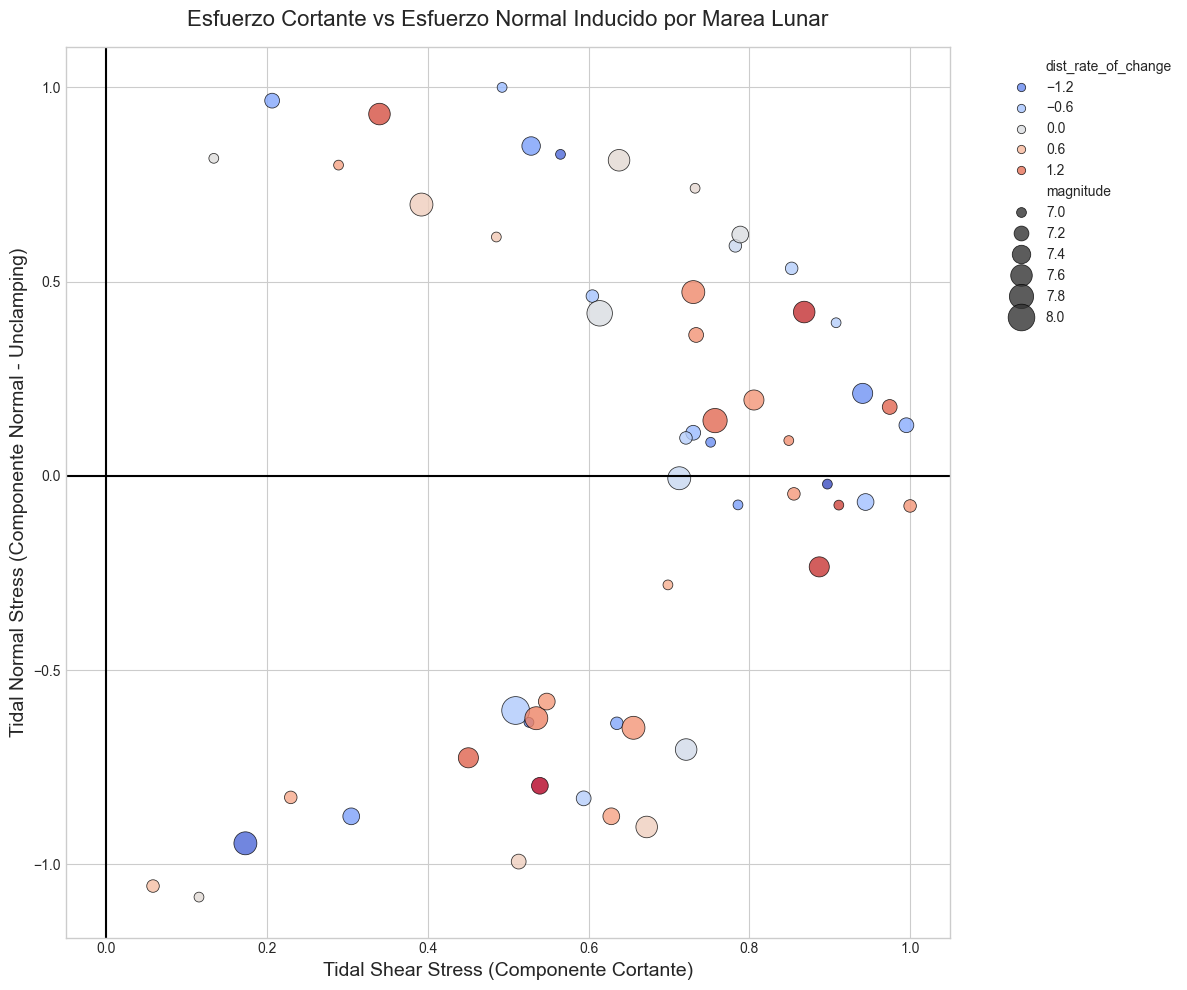

In [4]:
plt.figure(figsize=(12, 10))

# Crear el scatter plot
scatter = sns.scatterplot(
    data=df,
    x='tidal_shear_stress',
    y='tidal_normal_stress',
    hue='dist_rate_of_change',
    size='magnitude',
    sizes=(50, 400),
    palette='coolwarm',
    alpha=0.8,
    edgecolor='k'
)

# Cuadrantes y ejes
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)

# Mejorar el diseño
plt.title('Esfuerzo Cortante vs Esfuerzo Normal Inducido por Marea Lunar', fontsize=16, pad=15)
plt.xlabel('Tidal Shear Stress (Componente Cortante)', fontsize=14)
plt.ylabel('Tidal Normal Stress (Componente Normal - Unclamping)', fontsize=14)

# Mover la leyenda de tamaño fuera de la gráfica
handles, labels = scatter.get_legend_handles_labels()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Guardar figura
fig_path = '../results/figures/06_coulomb_vectors.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Gráfico de espacio vectorial guardado en: {fig_path}")

plt.show()

## 4. Exportar Dataset de Tensores
Guardamos este dataset final enriquecido mecánicamente.

In [5]:
export_path = '../data/processed/earthquakes_coulomb_stress.csv'
df.to_csv(export_path, index=False)
print(f"Dataset de tensores mecánicos exportado a: {export_path}")

Dataset de tensores mecánicos exportado a: ../data/processed/earthquakes_coulomb_stress.csv
